In [13]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Qtagg')
import matplotlib.pyplot as plt

import os
from scipy import*
from scipy import signal
from scipy.signal import find_peaks
row = np.arange(0,18,1)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
g = globals()
import matplotlib.colors as mcolors
from scipy.optimize import *
from itertools import *
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
from numpy import sqrt, min,max,sin,cos
# from mpl_toolkits.axes_grid.anchored_artists import AnchoredSizeBar

In [14]:

# 定义数据文件的相对路径
data_file = Path("..") / ".."/"20250215" / "Confocal" / "20250215-1717-36_confocal_xy_data.dat"
# 确保路径正确解析
print(f"解析后的绝对路径: {data_file.resolve()}")

# 检查文件是否存在
if data_file.exists():
    print("文件存在，准备读取数据")
 # 读取文件
    data = pd.read_csv(data_file, delimiter="\t", skiprows=row)
    print(data.head())
else:
    print("error 文件不存在，请检查路径是否正确！")



# removing unwanted columns
data = data.drop(["count rate /Dev2/AI1 (Hz)","count rate /Dev2/AI0 (Hz)",'z position (m)',"Unnamed: 6"], axis='columns')
#visualise the data

# sort the data according to the prefence
# must be sorted for depth analysis
data_sort = data.sort_values(by=['#x position (m)'],ignore_index = True)


解析后的绝对路径: E:\Project_Code\Exp_results\Zhuoyu_Poling\20250215\Confocal\20250215-1720-24_confocal_xy_data.dat
文件存在，准备读取数据
   #x position (m)  y position (m)  z position (m)  \
0         0.000060         0.00007          0.0001   
1         0.000061         0.00007          0.0001   
2         0.000061         0.00007          0.0001   
3         0.000062         0.00007          0.0001   
4         0.000063         0.00007          0.0001   

   count rate /Dev2/Ctr3 (Hz)  count rate /Dev2/AI1 (Hz)  \
0                     42340.0                   5.272686   
1                     37700.0                   5.437487   
2                     48720.0                   5.505579   
3                     37700.0                   5.539460   
4                     53940.0                   5.565447   

   count rate /Dev2/AI0 (Hz)  Unnamed: 6  
0                   5.669394         NaN  
1                   5.578276         NaN  
2                   5.558210         NaN  
3                   5.

In [15]:
# Shifting the origin to (0,0) and rescale the coordinate to real distance
data['#x position (m)'] = (data['#x position (m)']-data['#x position (m)'].min())*1e6*0.606
data['y position (m)'] = ((data['y position (m)']-data['y position (m)'].min())*1e6)*0.368
data

,#x position (m),y position (m),count rate /Dev2/Ctr3 (Hz)
0,0.000000,0.00,42340.0
1,0.447386,0.00,37700.0
2,0.894765,0.00,48720.0
3,1.342151,0.00,37700.0
4,1.789530,0.00,53940.0
...,...,...,...
16345,64.870482,29.44,37700.0
16346,65.317831,29.44,25520.0
16347,65.765241,29.44,39440.0
16348,66.212590,29.44,24940.0


# Plot editted figure

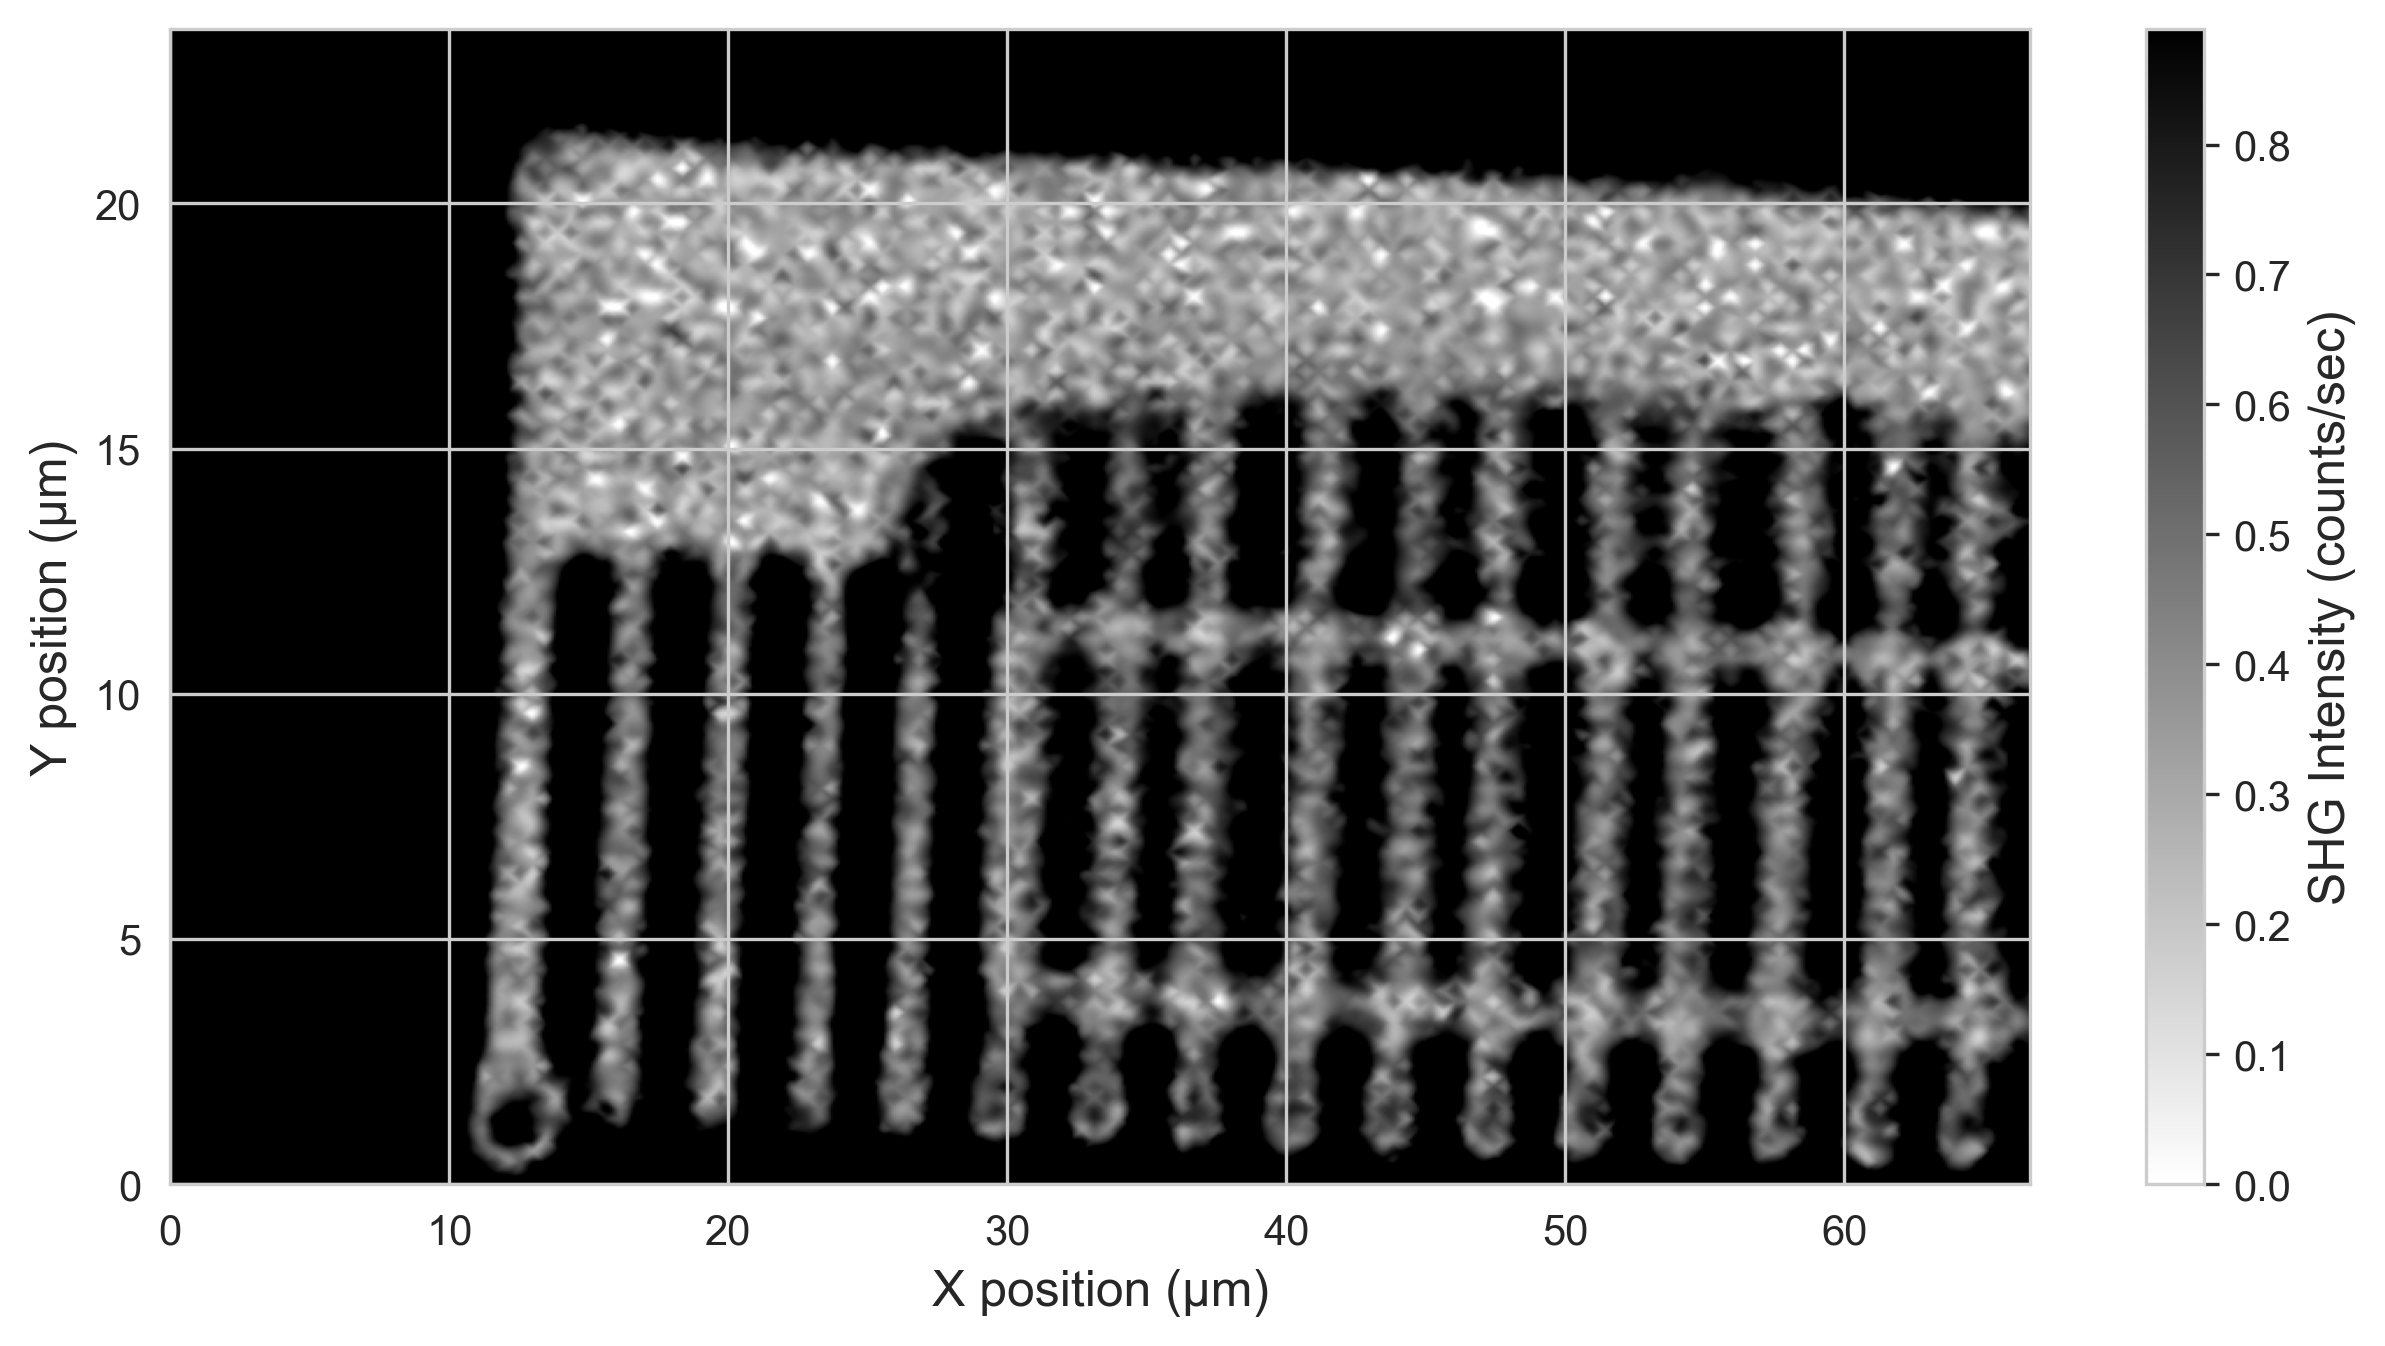

图片已保存到: E:\Project_Code\Exp_results\Zhuoyu_Poling\Editted_Fig\20250215-1720-24_confocal_xy_data_edited.png


In [16]:
import scipy.interpolate
# 自动生成保存路径
save_dir = Path("..") / ".." / "Editted_Fig"
save_dir.mkdir(parents=True, exist_ok=True)  # 确保目录存在

#  提取文件名，转换为 PNG
file_name = data_file.stem + "_edited.png"
save_path = save_dir / file_name

# 提取 X、Y、Z 数据
x = data['#x position (m)'].values   # 转换为 μm
y = data['y position (m)'].values
z = data['count rate /Dev2/Ctr3 (Hz)'].values  # 强度数据
z = sqrt(z)/sqrt(max(z))

# 计算 98% 最大值，避免极端点影响
v_max = np.percentile(z, 98)

# 构造规则网格
grid_x, grid_y = np.linspace(x.min(), x.max(), 800), np.linspace(y.min(), y.max(), 800)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

# 插值数据，使其适用于 imshow
grid_z = scipy.interpolate.griddata((x, y), z, (grid_x, grid_y), method='cubic')

# 画图
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
im = ax.imshow(grid_z*2, extent=[x.min(), x.max(), y.min(), y.max()*0.8], origin='lower',
               cmap='binary', aspect='auto', vmin=0, vmax=v_max)

# 添加 colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('SHG Intensity (counts/sec)', fontsize=12)

# 轴标签
ax.set_xlabel('X position (μm)', fontsize=12)
ax.set_ylabel('Y position (μm)', fontsize=12)

# 保存图片

plt.savefig(save_path, dpi=600, transparent=True, bbox_inches='tight')

plt.show()
print(f"图片已保存到: {save_path.resolve()}")

In [17]:
from scipy.signal.windows import gaussian
from scipy.signal import convolve


# 复制数据并筛选 poling 区域
df = data.copy()
df.drop(df[df['#x position (m)'] < 40].index, inplace=True)
#df.drop(df[df['#x position (m)'] >60].index, inplace=True)
#df.drop(df[df['y position (m)'] > 15].index, inplace=True)
#df.drop(df[df['y position (m)'] < 5].index, inplace=True)

# 提取 X 位置 和 SHG 信号
x_data = df['#x position (m)'].values
shg_intensity = df['count rate /Dev2/Ctr3 (Hz)'].values  # SHG 计数

# **Step 1: 归一化 SHG 信号**
shg_intensity = np.sqrt(shg_intensity)  # SHG 强度 ∝ \( d_{33}^2 \)，取平方根
shg_intensity /= np.max(shg_intensity)  # 归一化到 [0,1]



df['shg_intensity'] = shg_intensity  # 把平滑后的数据加入 DataFrame 里
df


,#x position (m),y position (m),count rate /Dev2/Ctr3 (Hz),shg_intensity
90,40.264458,0.00,42920.0,0.812843
91,40.711807,0.00,52200.0,0.896421
92,41.159217,0.00,46400.0,0.845154
93,41.606566,0.00,40020.0,0.784902
94,42.053976,0.00,45240.0,0.834523
...,...,...,...,...
16345,64.870482,29.44,37700.0,0.761812
16346,65.317831,29.44,25520.0,0.626783
16347,65.765241,29.44,39440.0,0.779194
16348,66.212590,29.44,24940.0,0.619620


4.45036928


C:\Users\Steven Yu\AppData\Local\Temp\ipykernel_16488\3677856958.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ticklabs, fontsize=20)


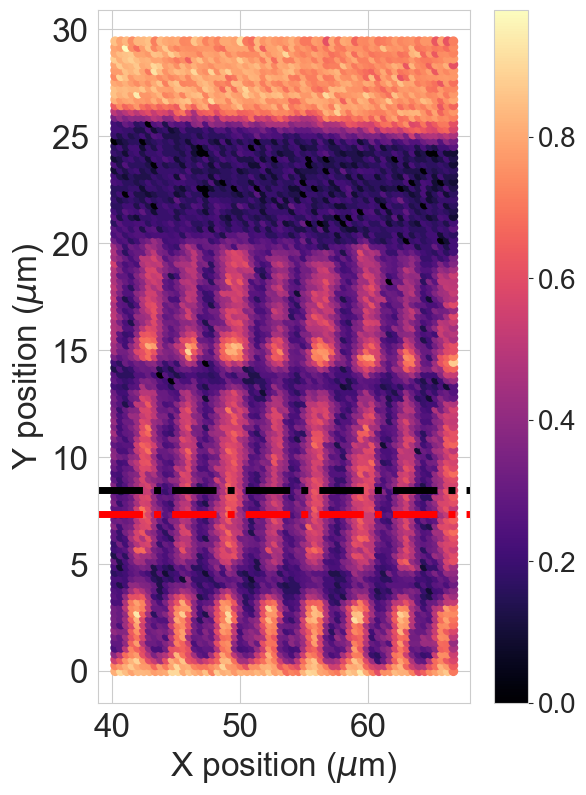

In [18]:

# here you verify the line you draw to see if you really get the electrode????
# md I wash the electrodes so hard to see the period or duty cycle
vmin = df['shg_intensity'].min()
#vmax = df['count rate /Dev2/Ctr3 (Hz)'].max()
vmax = 0.98
fig=plt.figure(figsize=(6,9))

#define the line for electrode reference
y_e = round(10*(len(df))/35)

print( df['y position (m)'].iloc[y_e]-4)
#plot the data
plt.scatter(x=df['#x position (m)'],y=df['y position (m)']
           ,c=df['shg_intensity'],cmap='magma',vmin=vmin,vmax=vmax)
plt.axhline(y = df['y position (m)'].iloc[y_e], color = 'black', linestyle = '-.',linewidth = 5)
plt.axhline(y = df['y position (m)'].iloc[round(4*(len(df))/16)], color = 'r', linestyle = '-.',linewidth = 5)
#plt.ylim(0,22)
# plt.axis('off')
plt.xlabel('X position ($\mu$m)',size = 24)
plt.ylabel('Y position ($\mu$m)',size = 24)
plt.tick_params(axis='both', labelsize=24)
cbar = plt.colorbar()
ticklabs = cbar.ax.get_yticklabels()
cbar.ax.set_yticklabels(ticklabs, fontsize=20)
# cbar.ax.set_title('SHG intensity (counts/sec)',fontsize=20,rotation = 90)
plt.tick_params(axis='both', labelsize=24)
file_prefix = data_file.stem  # 提取数据文件名
fig.savefig(save_dir / f"{file_prefix}_Sample_position.png", dpi=600, transparent=True, bbox_inches='tight')




# Finding Electrodes

✅ Selected dominant frequency near target: 0.2981 1/μm
domain width std: 0.53 μm
Poling Period 2T: 3.36 μm
Duty Cycle: 1.07
QPM Main Frequency: 0.2981 1/μm
QPM FFT Amplitude: 0.1694


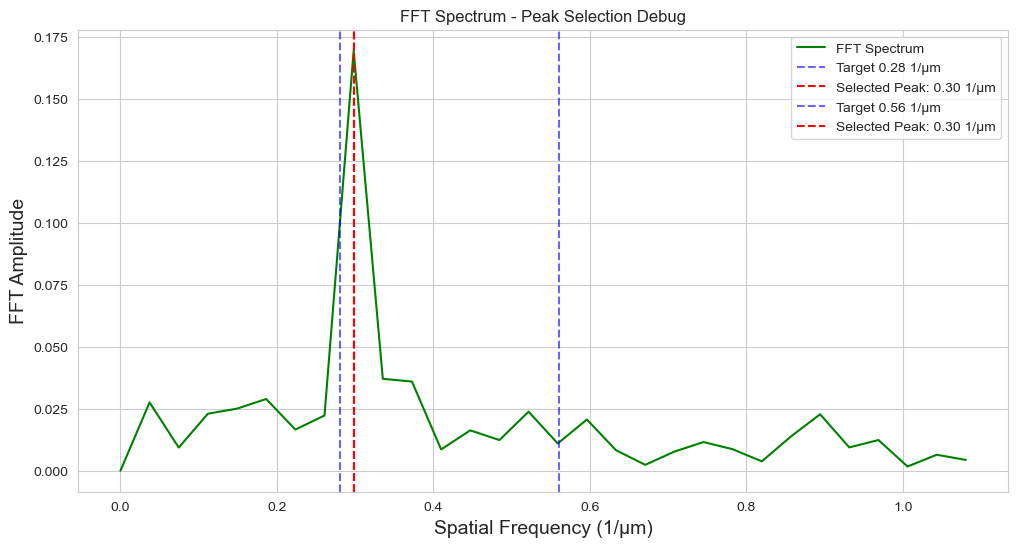

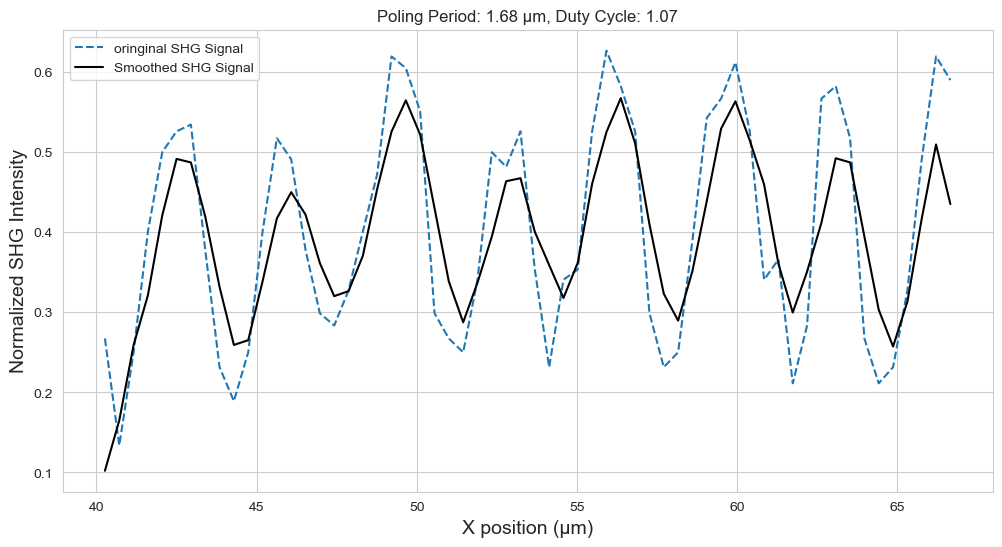

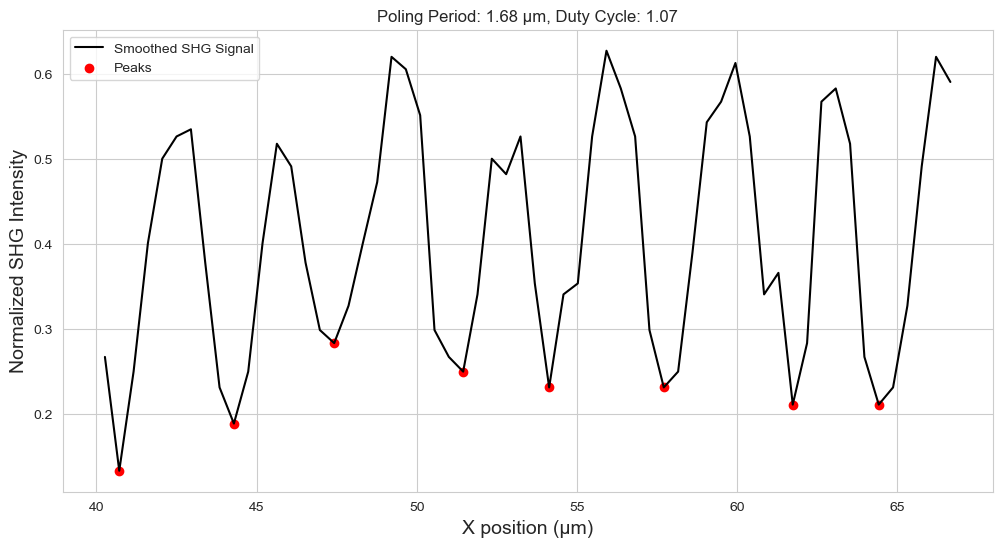

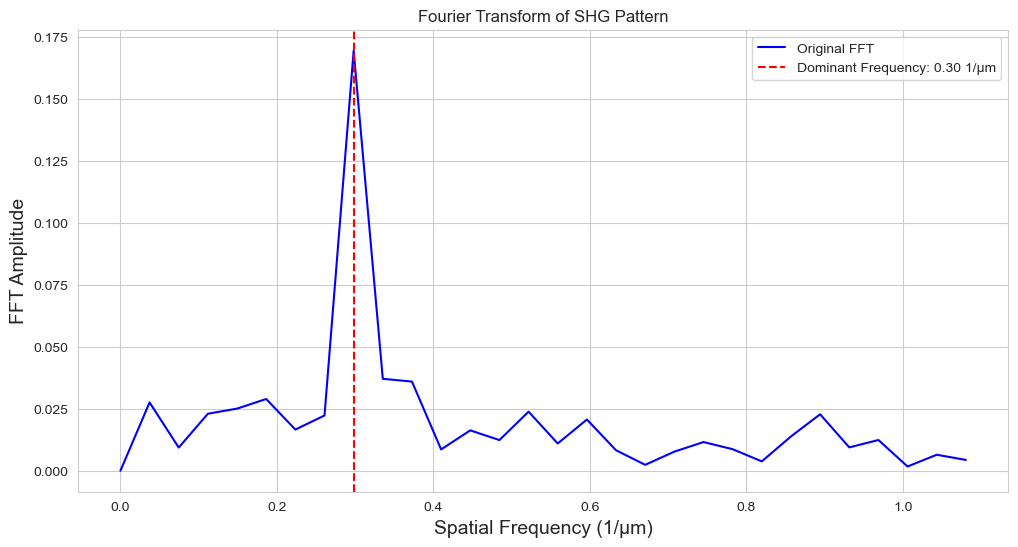

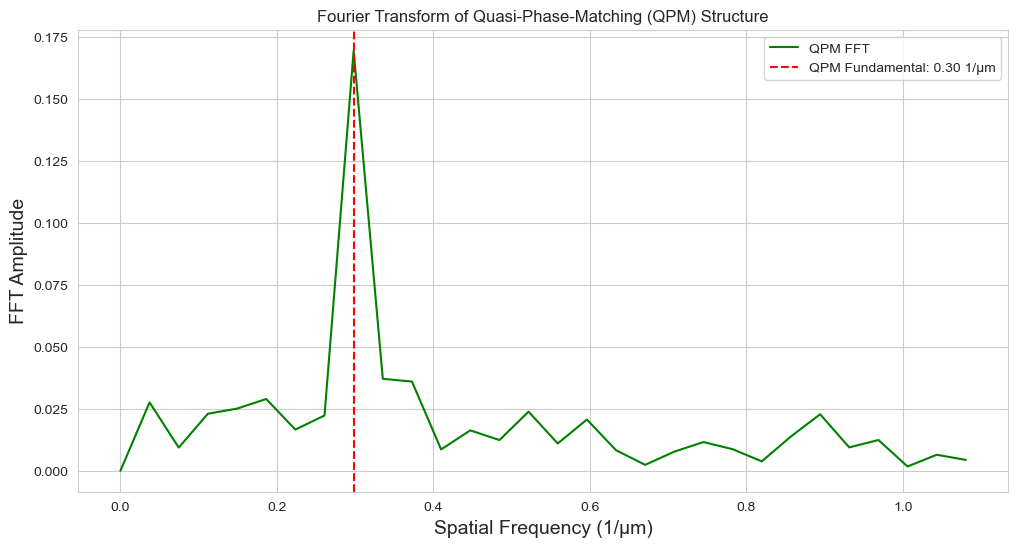

All images saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Editted_Fig


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import convolve, find_peaks
from scipy.signal.windows import gaussian
from scipy.fftpack import fft, fftfreq

# **Step 1: 提取 X 方向数据**
X_e, Z_e = [], []
if y_e >= len(df):
    y_e = len(df) - 1  # 避免索引越界
y_ref = df["y position (m)"].iloc[y_e]

for i in range(len(df)):
    y = df["y position (m)"].iloc[i]
    if np.isclose(y, y_ref, atol=1e-10):
        x = df["#x position (m)"].iloc[i]
        z = df['shg_intensity'].iloc[i]  # 归一化后的 d33 值
        X_e.append(x)
        Z_e.append(z)

x_e = np.asarray(X_e)
z_e = np.asarray(Z_e)

# 确保数据非空
if len(x_e) == 0 or len(z_e) == 0:
    raise ValueError("Error: No valid data points found!")

# **Step 2: 高斯滤波去噪**

gauss_window = gaussian(4, std=3)  # 创建高斯平滑窗口
gauss_window /= gauss_window.sum()
z_e_smooth = convolve(z_e, gauss_window, mode='same')

# **Step 3: FFT 计算主要频率**
N = len(x_e)
fft_y = fft(z_e - np.mean(z_e))  # 计算FFT，去掉 DC 分量
freqs = fftfreq(N, d=(x_e[1] - x_e[0]))  # 计算频率轴
fft_amplitude = 2/N*np.abs(fft_y)

# **Step 3.5: 找到所有峰值**
peak_indices, _ = find_peaks(fft_amplitude[:N // 2], height=0.3 * np.max(fft_amplitude[:N // 2]))  # 仅保留较大峰值
peak_freqs = freqs[peak_indices]  # 这些峰值对应的频率
peak_amplitudes = fft_amplitude[peak_indices]  # 这些峰值的 FFT 振幅

# **Step 3.6: 查找 0.28 和 0.56 附近的 peak**
target_freqs = [0.28, 0.56]  # 目标频率
freq_tolerance = 0.05  # 允许的误差范围 ±0.05/μm

selected_freq = None
selected_amplitude = None

# **查找 0.28 和 0.56 附近的 peak**
for target_freq in target_freqs:
    valid_indices = \
    np.where((peak_freqs >= target_freq - freq_tolerance) & (peak_freqs <= target_freq + freq_tolerance))[0]

    if len(valid_indices) > 0:
        max_idx = valid_indices[np.argmax(peak_amplitudes[valid_indices])]
        peak_freq = peak_freqs[max_idx]
        peak_amplitude = peak_amplitudes[max_idx]

        # 选择较大的 peak
        if selected_amplitude is None or peak_amplitude > selected_amplitude:
                selected_freq = peak_freq
                selected_amplitude = peak_amplitude

# **如果 0.28 和 0.56 附近都没有 peak，则选择全局最大峰值**
if selected_freq is None:
        dominant_freq_idx = np.argmax(fft_amplitude[:N // 2])  # 最高值索引
        selected_freq = freqs[dominant_freq_idx]
        selected_amplitude = fft_amplitude[dominant_freq_idx]
        print(f"⚠️ No peak near 0.28 or 0.56/μm, using global max frequency: {selected_freq:.4f} 1/μm")
else:
    print(f"✅ Selected dominant frequency near target: {selected_freq:.4f} 1/μm")
dominant_freq = selected_freq
# **计算 Poling 周期**
T = 1 / abs(selected_freq)
if T > 30:
    print(f"⚠️ {data_file.name}: Computed Poling Period too large (2T={2 * T:.2f} μm), skipping...")

 # **Step 3.7: 画图保存 FFT 频谱，方便 debug**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs[:N // 2], fft_amplitude[:N // 2], color='g', label="FFT Spectrum")

# **标记 0.28 和 0.56 处的候选峰值**
for target_freq in target_freqs:
    ax.axvline(x=target_freq, color='b', linestyle="--", alpha=0.6, label=f"Target {target_freq:.2f} 1/μm")

    # **标记最终选择的频率**
    ax.axvline(x=selected_freq, color='r', linestyle="--", label=f"Selected Peak: {selected_freq:.2f} 1/μm")

    # **添加图例、标签**
    ax.set_xlabel("Spatial Frequency (1/μm)", size=14)
    ax.set_ylabel("FFT Amplitude", size=14)
    ax.set_title("FFT Spectrum - Peak Selection Debug")
    ax.legend()

    # **自动保存图片**
    fig.savefig(save_dir / f"{data_file.stem}_FFT_Debug.png",
                dpi=600, transparent=True, bbox_inches='tight')
T = 1 / abs(dominant_freq)
flip =1
if T>2:
    T = T/2
    flip=0
# **Step 4: 计算占空比**
min_peak_distance = 1 / (x_e[1] - x_e[0])  # 计算对应的数据点数
peaks, _ = find_peaks(abs(1-z_e), height=np.percentile(abs(1-z_e), 50),distance=min_peak_distance)  # 50% 阈值寻找 peaks
if len(peaks) > 1:
    domain_widths = np.diff(peaks)  # 计算 poling 结构宽度
    duty_cycle = np.min(domain_widths) /2/ T  # 计算占空比
else:
    duty_cycle = None
# **Step 2: 计算占空比 (Duty Cycle)**
print(f"domain width std: {np.std(domain_widths*(x_e[1]-x_e[0])):.2f} μm")
if T:
    duty_cycle = np.median(domain_widths)*(x_e[1]-x_e[0]) /2/ T  # 计算占空比
    print(f"Poling Period 2T: {2*T:.2f} μm")
    print(f"Duty Cycle: {duty_cycle:.2f}")
else:
    duty_cycle = None
    print("Error: Duty Cycle 计算失败")
# **Step 5: 反转 d_eff 符号**

x_shifted = x_e-x_e[peaks[0]]

if flip:
    deff_signs = np.sign(np.sin(2 * np.pi /(2*T) * x_e))  # 用正弦信号反转
    z_e_reversed = z_e * deff_signs
    # 计算翻转区域
    flip_regions = deff_signs < 0  # 负值区域

    # 绘制图像
    plt.figure(figsize=(10, 5))
    plt.plot(x_e, z_e, label="Original $z_e$", linestyle='-', color='b')
    plt.plot(x_e, z_e_reversed, label="Reversed $z_e$", linestyle='--', color='r')

    # 颜色填充不同区域
    plt.fill_between(x_e, z_e.min(), z_e.max(), where=flip_regions, color='red', alpha=0.2, label="Flipped Region")
    plt.fill_between(x_e, z_e.min(), z_e.max(), where=~flip_regions, color='blue', alpha=0.2, label="Unflipped Region")

    # 图例和标签
    plt.xlabel("x")
    plt.ylabel("z_e values")
    plt.title("Comparison of $z_e$ and Reversed $z_e$")
    plt.legend()
    plt.grid(True)

    # 显示图像
    plt.show()
else:
    z_e_reversed =z_e

# **Step 6: FFT 计算 QPM 结构**
fft_y_qpm = fft(z_e_reversed - np.mean(z_e_reversed))  # 计算 QPM 结构的 FFT
fft_amplitude_qpm = 2/N*np.abs(fft_y_qpm)
# 找到 QPM 结构的主要频率分量
qpm_peak_idx = np.argmax(fft_amplitude_qpm[1:N//2])  # 跳过 DC 分量
qpm_peak_freq = freqs[1:N//2][qpm_peak_idx]  # QPM 主要频率
qpm_peak_amplitude = fft_amplitude_qpm[qpm_peak_idx+1]  # QPM 对应幅度

# 打印结果
print(f"QPM Main Frequency: {qpm_peak_freq:.4f} 1/μm")
print(f"QPM FFT Amplitude: {qpm_peak_amplitude:.4f}")
# **自动生成文件名前缀**
file_prefix = data_file.stem  # 提取数据文件名

# **Step 7: 绘制并比较 SHG 信号平滑效果**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_e,z_e,label="oringinal SHG Signal",linestyle="--")
ax.plot(x_e, z_e_smooth, label="Smoothed SHG Signal", color="k")
ax.set_xlabel("X position (μm)", size=14)
ax.set_ylabel("Normalized SHG Intensity", size=14)
ax.legend()
ax.set_title(f"Poling Period: {T:.2f} μm, Duty Cycle: {duty_cycle:.2f}" if duty_cycle else "No Period Detected")
fig.savefig(save_dir / f"{file_prefix}_SHG_signal.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 7: 绘制并保存 SHG 信号**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_e, z_e, label="Smoothed SHG Signal", color="k")
ax.scatter(x_e[peaks], z_e[peaks], color='r', label="Peaks")
ax.set_xlabel("X position (μm)", size=14)
ax.set_ylabel("Normalized SHG Intensity", size=14)
ax.legend()
ax.set_title(f"Poling Period: {T:.2f} μm, Duty Cycle: {duty_cycle:.2f}" if duty_cycle else "No Period Detected")
fig.savefig(save_dir / f"{file_prefix}_SHG_signal.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 8: 绘制并保存 FFT 频谱**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs[:N//2], fft_amplitude[:N//2], color='b', label="Original FFT")
ax.axvline(x=dominant_freq, color='r', linestyle="--", label=f"Dominant Frequency: {dominant_freq:.2f} 1/μm")
ax.set_xlabel("Spatial Frequency (1/μm)", size=14)
ax.set_ylabel("FFT Amplitude", size=14)
ax.set_title("Fourier Transform of SHG Pattern")
ax.legend()
fig.savefig(save_dir / f"{file_prefix}_FFT.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 9: 绘制并保存 QPM 结构的 FFT 频谱**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs[:N//2], fft_amplitude_qpm[:N//2], color='g', label="QPM FFT")
ax.axvline(x=qpm_peak_freq, color='r', linestyle="--", label=f"QPM Fundamental: {qpm_peak_freq:.2f} 1/μm")
ax.set_xlabel("Spatial Frequency (1/μm)", size=14)
ax.set_ylabel("FFT Amplitude", size=14)
ax.set_title("Fourier Transform of Quasi-Phase-Matching (QPM) Structure")
ax.legend()
fig.savefig(save_dir / f"{file_prefix}_QPM_FFT.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

print(f"All images saved to: {save_dir.resolve()}")


# prepare some parameters

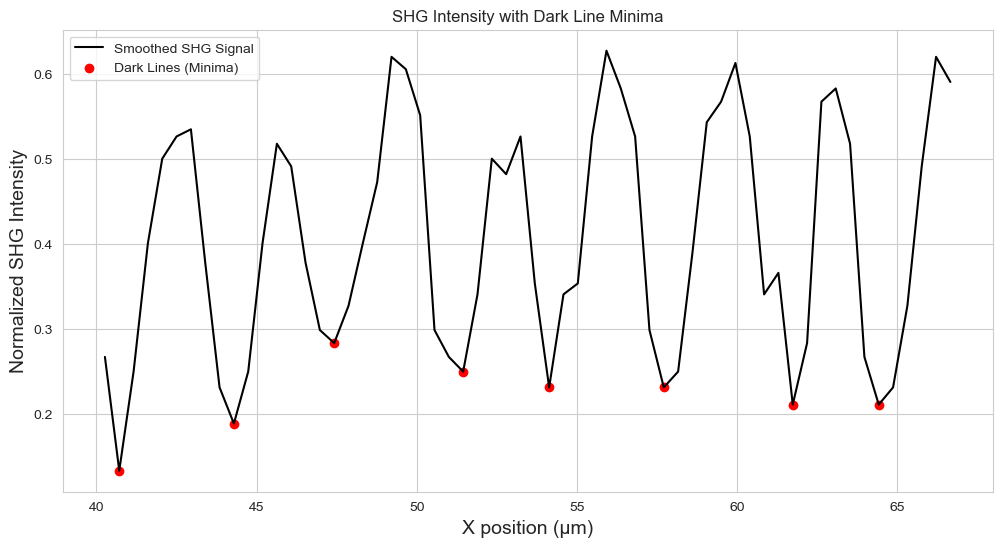

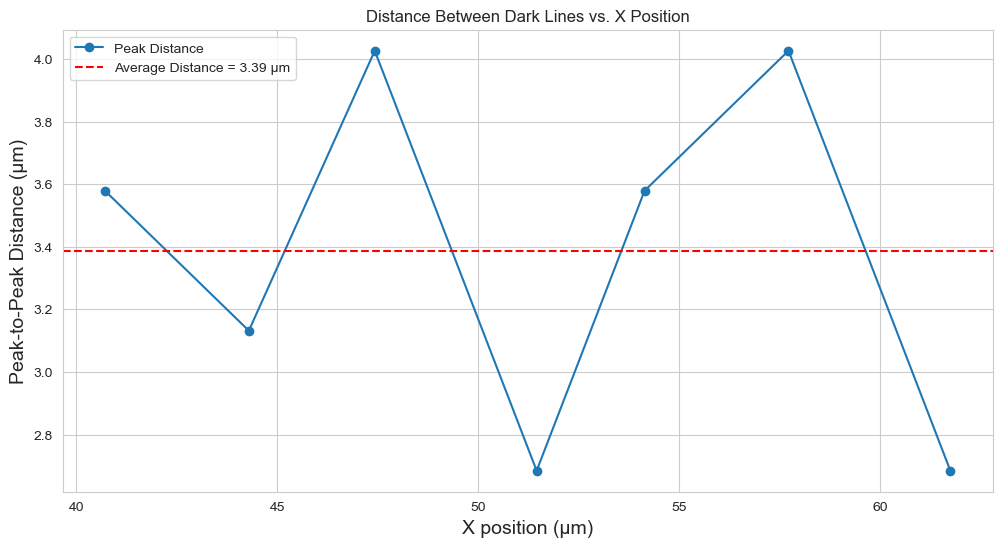

Duty Cycle: 1.06
All images saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Processed_Figures


In [20]:
# **Step 2: 设定最小间距 distance = 0.9 μm**
min_peak_distance = 0.9 / (x_e[1] - x_e[0])  # 计算对应的数据点数
dark_peaks, _ = find_peaks(-z_e, distance=min_peak_distance,prominence=0.05)  # 找极小值

# **Step 3: 计算相邻 peak 之间的距离**
if len(dark_peaks) > 1:
    peak_distances = np.diff(x_e[dark_peaks])  # 计算两个极小值之间的间距
    avg_distance = np.mean(peak_distances)  # 计算平均周期
else:
    peak_distances = []
    avg_distance = None

# **自动生成文件名前缀**
file_prefix = data_file.stem  # 获取输入数据文件名
save_dir = Path("..") / ".." / "Processed_Figures"
save_dir.mkdir(parents=True, exist_ok=True)  # 确保目录存在

# **Step 4: 画出 SHG 信号 + 极小值**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_e, z_e, label="Smoothed SHG Signal", color="k")
ax.scatter(x_e[dark_peaks], z_e[dark_peaks], color='r', label="Dark Lines (Minima)")
ax.set_xlabel("X position (μm)", size=14)
ax.set_ylabel("Normalized SHG Intensity", size=14)
ax.legend()
ax.set_title("SHG Intensity with Dark Line Minima")

# **保存图像**
fig.savefig(save_dir / f"{file_prefix}_Dark_Lines.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 5: 画出 peak 之间的间距 vs X**
if len(peak_distances) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_e[dark_peaks[:-1]], peak_distances, marker='o', linestyle='-', label="Peak Distance")
    ax.axhline(y=avg_distance, color='r', linestyle="--", label=f"Average Distance = {avg_distance:.2f} μm")
    ax.set_xlabel("X position (μm)", size=14)
    ax.set_ylabel("Peak-to-Peak Distance (μm)", size=14)
    ax.legend()
    ax.set_title("Distance Between Dark Lines vs. X Position")

    # **保存图像**
    fig.savefig(save_dir / f"{file_prefix}_Peak_Distance.png", dpi=600, transparent=True, bbox_inches='tight')
    plt.show()
else:
    print("Error: Not enough peaks found to compute distances.")

# **Step 6: 计算占空比**
if avg_distance and len(peak_distances) > 0:
    if avg_distance<2:
        duty_cycle = np.median(peak_distances) / (2 * avg_distance)
    else:
        duty_cycle = np.median(peak_distances) / ( avg_distance)
    print(f"Duty Cycle: {duty_cycle:.2f}")
else:
    print("Error: Cannot compute duty cycle")

print(f"All images saved to: {save_dir.resolve()}")


# Easily analyse the duty cycle vs distance from electrode tip

# here we draw lines to distinguish different domain????

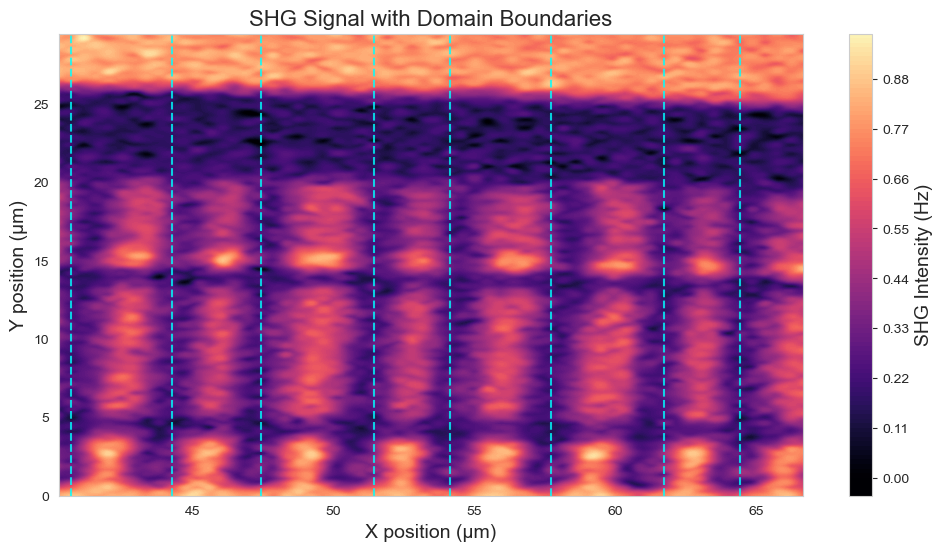

Image saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Processed_Figures\20250215-1720-24_confocal_xy_data_Domain_Boundaries.png


In [21]:
import scipy.interpolate as interp
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
# Load Data (Assume df is already loaded)
x = df['#x position (m)']
y = df['y position (m)']
z = df['shg_intensity']

# Convert x, y to microns for better visualization
x = x   # Convert to µm
y = y  # Convert to µm

# Create a grid for interpolation
num_grid = 600  # Define grid resolution
x_grid = np.linspace(x.min(), x.max(), num_grid)
y_grid = np.linspace(y.min(), y.max(), num_grid)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Interpolate to get a smooth intensity map
Z_grid = interp.griddata((x, y), z, (X_grid, Y_grid), method='cubic')

# Apply Gaussian filter for extra smoothness
Z_grid = gaussian_filter(Z_grid, sigma=1.5)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
cmap = 'magma'  # Choose a nice colormap

# Use contourf for a smooth filled map
contour = ax.contourf(X_grid, Y_grid, Z_grid, levels=100, cmap=cmap, norm=Normalize(vmin=np.nanmin(z), vmax=np.nanmax(z)))

# Add domain boundaries using `axvline`
for x_peak in x_e[dark_peaks]:
    ax.axvline(x_peak, linestyle='--', color='cyan', linewidth=1.5, alpha=0.8)

# Labels & Colorbar
ax.set_xlabel("X position (μm)", fontsize=14)
ax.set_ylabel("Y position (μm)", fontsize=14)
ax.set_title("SHG Signal with Domain Boundaries", fontsize=16)
cbar = fig.colorbar(contour)
cbar.set_label("SHG Intensity (Hz)", fontsize=14)

# Save high-quality figure
save_path = save_dir / f"{file_prefix}_Domain_Boundaries.png"
fig.savefig(save_path, dpi=600, transparent=True, bbox_inches='tight')

# Show plot
plt.show()
print(f"Image saved to: {save_path.resolve()}")



ValueError: x and y must have same first dimension, but have shapes (21,) and (1,)

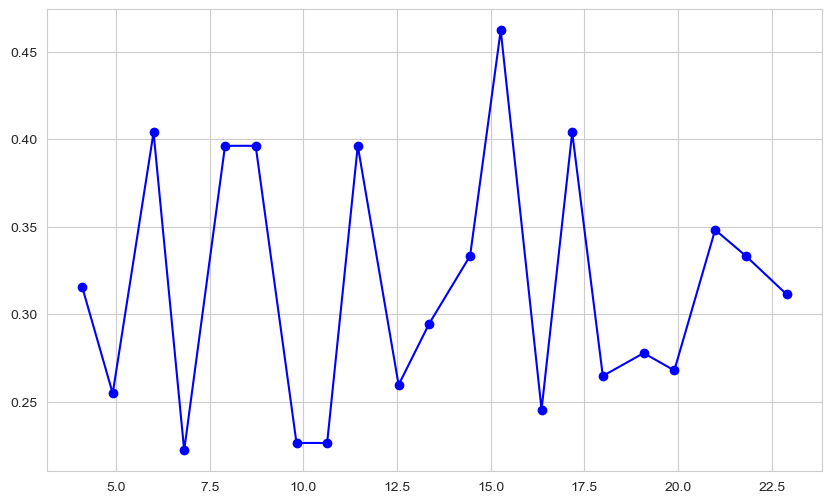

In [22]:

# **自动生成文件名前缀**
file_prefix = data_file.stem  # 获取输入数据文件名
save_dir = Path("..") / ".." / "Processed_Figures"
save_dir.mkdir(parents=True, exist_ok=True)  # 确保目录存在
y_e = np.linspace(round(5*(len(df))/35),round(27*(len(df))/35),num=21)
# **Step 1: 设定 y_e 的扫描范围**
y_e_values = df["y position (m)"].iloc[y_e]
duty_cycles = []  # 存储计算出的占空比
valid_y_e = []  # 存储有效的 y_e

for y_e in y_e_values:
    # **Step 2: 提取 X 方向数据**
    X_e, Z_e = [], []
    for i in range(len(df)):
        y = df["y position (m)"].iloc[i]
        if np.isclose(y, y_e, atol=0.1):  # 找到接近 y_e 的数据点
            x = df["#x position (m)"].iloc[i]
            z = df['shg_intensity'].iloc[i]
            X_e.append(x)
            Z_e.append(z)

    x_e = np.asarray(X_e)
    z_e = np.asarray(Z_e)

    # **Step 3: 确保数据非空**
    if len(x_e) == 0 or len(z_e) == 0:
        continue  # 跳过该 y_e

    # **Step 4: 高斯滤波去噪**
    gauss_window = gaussian(4, std=3)
    gauss_window /= gauss_window.sum()
    z_e_smooth = convolve(z_e, gauss_window, mode='same')

    # **Step 5: 设定最小间距 distance**
    min_peak_distance = 1 / (x_e[1] - x_e[0])  # 计算对应的数据点数
    dark_peaks, _ = find_peaks(-z_e, distance=min_peak_distance)  # 找极小值

    # **Step 6: 计算相邻 peak 之间的距离**
    if len(dark_peaks) > 1:
        peak_distances = np.diff(x_e[dark_peaks])
        avg_distance = np.mean(peak_distances)
    else:
        peak_distances = []
        avg_distance = None

    # **Step 7: 计算占空比**
    if avg_distance and len(peak_distances) > 0:
        duty_cycle = min(peak_distances) / (2 * avg_distance)
        duty_cycles.append(duty_cycle)
        valid_y_e.append(y_e)  # 记录有效的 y_e

# **Step 8: 绘制占空比 vs. y_e**
plt.figure(figsize=(10, 6))
plt.plot(valid_y_e, duty_cycles, marker='o', linestyle='-', color='b', label="Duty Cycle")
plt.plot(valid_y_e,np.std(peak_distances),marker='o', linestyle='--', color='k', label="STD width")
plt.xlabel("Y Position (μm)", fontsize=14)
plt.ylabel("Duty Cycle", fontsize=14)
plt.title("Duty Cycle vs. Distance from Electrode", fontsize=16)
plt.legend()
plt.grid(True)

# **保存图片**
plt.savefig(save_dir / f"{file_prefix}_DutyCycle_vs_Y.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

print(f"📊 Duty Cycle vs. Y plot saved as {file_prefix}_DutyCycle_vs_Y.png")
